# Lecture 04 Practical — K-means Clustering, from First Principles to New Predictions

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc Artificial Intelligence and Machine Learning · **Lecture:** 04  
**Learning outcomes:** **MLO1** (explain AI/ML techniques and applications), **MLO3** (use relevant data and software environments), with additional algorithm-evaluation practice useful for MLO4.  
**Suggested duration:** 90–120 minutes, with optional extension exercises.

### The question
> Given observations with two numerical attributes, can we discover groups of similar observations **without being told their class labels**?

K-means is an **unsupervised learning** algorithm. It places `K` centroids, assigns each point to its nearest centroid, recomputes the centroid of each group, and repeats until assignments stabilise (or a stopping criterion is reached).

**What we will learn to do:**
1. Inspect the lecturer's **original** 33 observations and explain why a larger example helps teaching.
2. Examine an improved **343-row synthetic teaching dataset** that preserves all 33 original points.
3. Understand distances, cluster assignment and centroid updates **by hand**.
4. Scale features appropriately and compare candidate values of `K` using the elbow and silhouette methods.
5. Train K-means, plot the groups, interpret centroids and evaluate clustering quality.
6. Assign **new unseen coordinates** to learned groups and explain the limitations.

**Important:** The features `x` and `y` are generic teaching coordinates. They are **not** patient, student or customer records, and their values should not be given a real-world interpretation. Every added row is simulated; simulated observations are clearly identified in the CSV. No known class labels are provided for training.

## 0. Before you run

Put these two files in the **same folder** as this notebook:
- `Kmean2_original.csv`: the original 33 observations, kept unchanged in numerical content.
- `Kmean2_improved.csv`: the same 33 observations plus 310 **simulated** observations. Columns: `observation_id`, `x`, `y`, and `source`.

You can run this notebook in Jupyter Notebook, JupyterLab or VS Code using the following libraries:

```bash
pip install numpy pandas matplotlib scikit-learn
```

All code examples use fixed random seeds for reproducibility. Charts are generated directly from the dataset and model; no diagrams are pasted in from external sources.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, adjusted_rand_score

DATA_FOLDER = Path('.')
original = pd.read_csv(DATA_FOLDER / 'Kmean2_original.csv')
data = pd.read_csv(DATA_FOLDER / 'Kmean2_improved.csv')
print('Original observations:', len(original))
print('Improved observations:', len(data))
print('Columns:', list(data.columns))
print('Libraries loaded successfully.')

Original observations: 33
Improved observations: 343
Columns: ['observation_id', 'x', 'y', 'source']
Libraries loaded successfully.


## 1. Start with the original example

The original notebook reads the CSV, makes a scatterplot, fits `KMeans(n_clusters=5)` and plots the points with different colours. That is a useful starting point, but there are some teaching issues:

- It **chooses 5 clusters without explaining why**.
- Some groups have very few points: a single observation near `(12, 7)` does not reliably define a population group.
- It plots points **connected by lines**, although each row is an independent observation. Connecting them suggests an ordering or time sequence that the data do not contain.
- It does not evaluate the clusters, standardise features, explore sensitivity, or classify a new point.

We will retain the original information and correct these weaknesses step by step.

  x    y
1.0  3.0
2.0  4.0
3.0  3.0
6.0 20.0
6.2 21.0
6.5 22.0
5.8 22.0
7.0 23.0

Original dataset summary:
           x      y
count  33.00  33.00
mean    6.18  15.63
std     3.93   8.26
min     1.00   2.00
25%     2.00   5.00
50%     6.50  20.00
75%    10.40  22.00
max    12.00  25.00


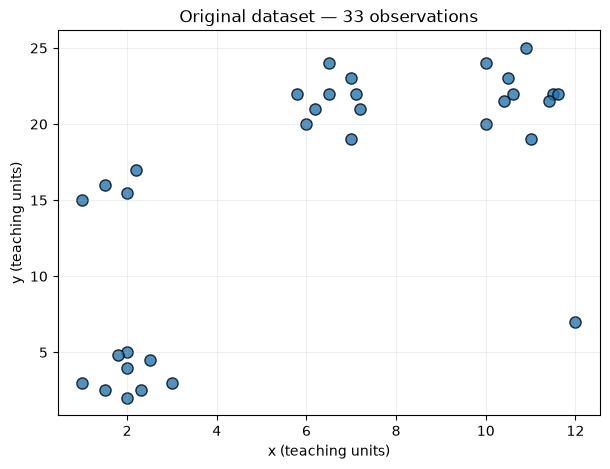

In [2]:
print(original.head(8).to_string(index=False))
print('\nOriginal dataset summary:')
print(original.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(original['x'], original['y'], s=65, edgecolor='black', alpha=.8)
ax.set(title='Original dataset — 33 observations', xlabel='x (teaching units)', ylabel='y (teaching units)')
ax.grid(alpha=.2)
plt.show()

### Reflect — what is a cluster?

Point similarity will be defined using the distance between two coordinates. If two points are near each other, K-means may assign them to the same group. Whether that group is **meaningful** in a real application is a separate question requiring subject-matter knowledge.

**Question:** Why is it dangerous to infer a stable cluster from only one observation?

## 2. Study the improved dataset

The improved CSV preserves all 33 original `(x, y)` pairs, then adds **310 synthetic coordinates** sampled around five well-separated regions of the plot. They are intentionally easy to distinguish because this is an introductory exercise.

We will **not** train the algorithm using `observation_id` or `source`:
- `observation_id` only identifies a row.
- `source` only records whether the row was part of the lecturer's original data or was added by simulation.
- Only `x` and `y` represent numerical features suitable for this example.

**Caution:** Artificial clusters usually look cleaner than those encountered in operational datasets. A high score on this exercise is not proof that K-means will work as well with real data.

In [3]:
print('Missing values:')
print(data.isna().sum().to_string())
print('\nSource counts:')
print(data['source'].value_counts().to_string())
print('\nFirst few observations:')
print(data.head(6).to_string(index=False))
assert data[['x', 'y']].notna().all().all()
assert len(data) == 343
assert np.allclose(data.loc[:32, ['x', 'y']].to_numpy(), original[['x', 'y']].to_numpy())

Missing values:
observation_id    0
x                 0
y                 0
source            0

Source counts:
source
Simulated extension    310
Original 33 points      33

First few observations:
observation_id   x    y             source
       OBS-001 1.0  3.0 Original 33 points
       OBS-002 2.0  4.0 Original 33 points
       OBS-003 3.0  3.0 Original 33 points
       OBS-004 6.0 20.0 Original 33 points
       OBS-005 6.2 21.0 Original 33 points
       OBS-006 6.5 22.0 Original 33 points


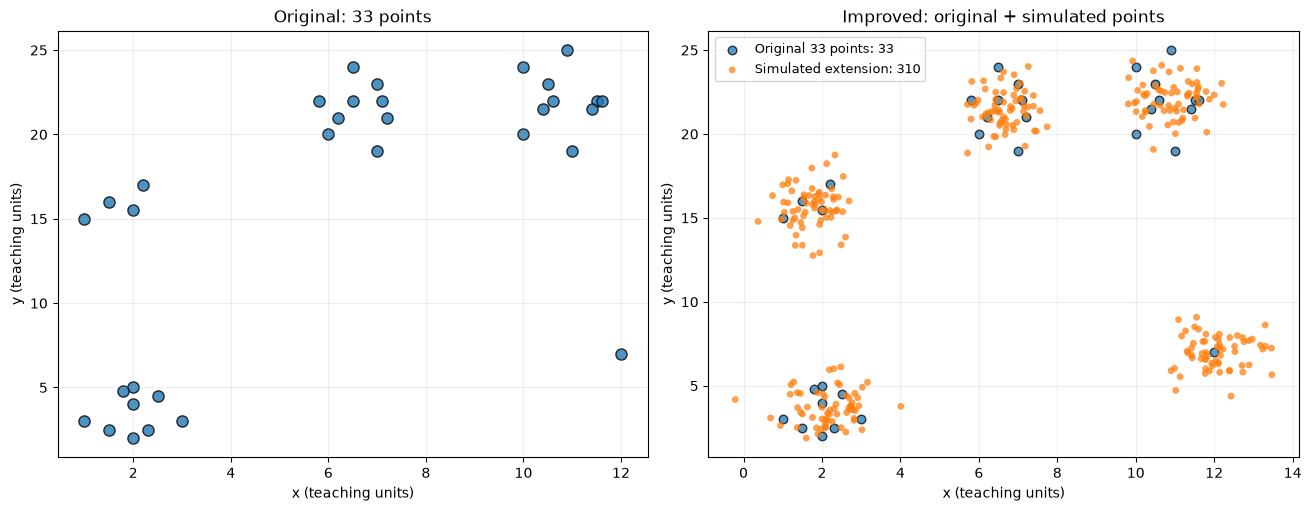

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(original['x'], original['y'], s=65, edgecolor='black', alpha=.8)
axes[0].set_title('Original: 33 points')
for label, subset in data.groupby('source'):
    axes[1].scatter(subset['x'], subset['y'], s=38 if label.startswith('Original') else 24,
                    alpha=.75, label=f'{label}: {len(subset)}', edgecolor='black' if label.startswith('Original') else 'none')
axes[1].set_title('Improved: original + simulated points')
axes[1].legend(fontsize=9)
for ax in axes:
    ax.set(xlabel='x (teaching units)', ylabel='y (teaching units)')
    ax.grid(alpha=.2)
plt.show()

## 3. The idea behind K-means: two operations

For a point \(p=(x,y)\) and a centroid \(c=(a,b)\), Euclidean distance is

\[
d(p,c)=\sqrt{(x-a)^2+(y-b)^2}.
\]

K-means alternates between these operations:

1. **Assignment:** Assign each observation to the *nearest* centroid.
2. **Update:** Move every centroid to the *mean* of all observations assigned to that centroid.

The algorithm attempts to minimise **within-cluster sum of squared distances** (inertia):

\[
J=\sum_{i=1}^{n}\lVert x_i-\mu_{z_i}\rVert^2,
\]

where \(z_i\) indicates the assigned cluster and \(\mu_{z_i}\) is its centroid.

The objective does not use known class labels. The cluster IDs `0`, `1`, etc. are arbitrary: `cluster 0` does not automatically mean "best" or "worst".

### A tiny manual example (before using scikit-learn)

Take six points, start with **two** initial centroids, and perform **one** assignment and update. This miniature problem makes the underlying mathematics visible before we use a software library.

In [5]:
tiny = np.array([[1.0, 1.0], [1.5, 2.0], [2.2, 1.2], [7.8, 8.5], [8.5, 8.0], [9.0, 9.2]])
initial_centroids = np.array([[1.0, 1.0], [9.0, 9.0]])
distances = np.sqrt(((tiny[:, None, :] - initial_centroids[None, :, :])**2).sum(axis=2))
assignments = distances.argmin(axis=1)
updated_centroids = np.array([tiny[assignments == j].mean(axis=0) for j in range(2)])
trace = pd.DataFrame({'x': tiny[:, 0], 'y': tiny[:, 1],
                      'distance_to_C0': distances[:, 0].round(2),
                      'distance_to_C1': distances[:, 1].round(2),
                      'assigned_centroid': assignments})
print(trace.to_string(index=False))
print('\nInitial centroids:\n', initial_centroids)
print('Centroids after one update:\n', updated_centroids.round(2))

  x   y  distance_to_C0  distance_to_C1  assigned_centroid
1.0 1.0            0.00           11.31                  0
1.5 2.0            1.12           10.26                  0
2.2 1.2            1.22           10.35                  0
7.8 8.5           10.12            1.30                  1
8.5 8.0           10.26            1.12                  1
9.0 9.2           11.46            0.20                  1

Initial centroids:
 [[1. 1.]
 [9. 9.]]
Centroids after one update:
 [[1.57 1.4 ]
 [8.43 8.57]]


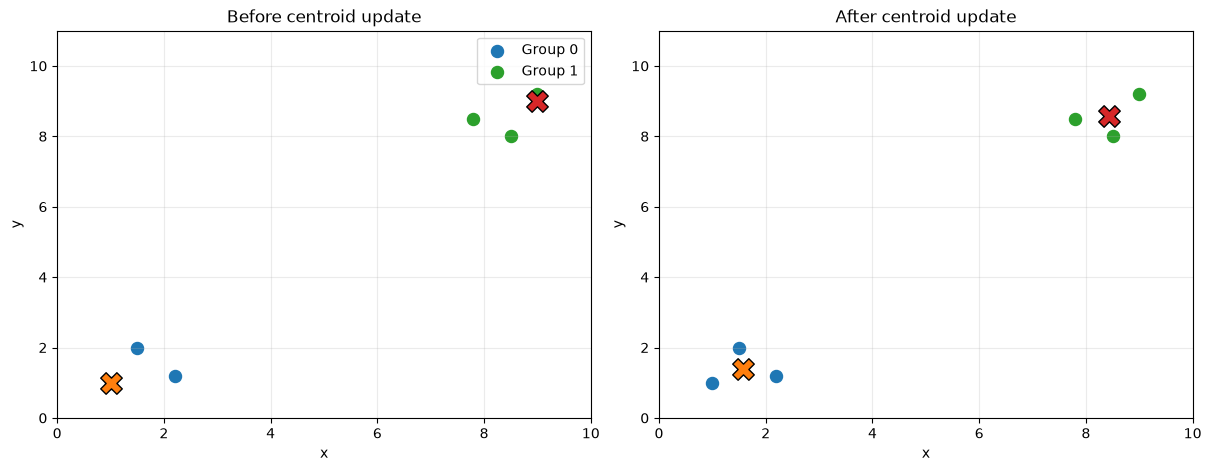

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ax, cents, ttl in zip(axes, [initial_centroids, updated_centroids],
                          ['Before centroid update', 'After centroid update']):
    for j in range(2):
        pts = tiny[assignments == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=75, label=f'Group {j}')
        ax.scatter(cents[j, 0], cents[j, 1], marker='X', s=240, edgecolor='black')
    ax.set(title=ttl, xlabel='x', ylabel='y', xlim=(0, 10), ylim=(0, 11))
    ax.grid(alpha=.25)
axes[0].legend()
plt.show()

**Discuss:** Why does the mean of the assigned points make a natural centroid? What would change if we moved the first centroid farther away? Why might different initial centroids result in different cluster solutions?

## 4. Prepare features carefully

Because K-means compares distances, the **measurement scale** matters. If `y` ranges over much larger values than `x`, it can dominate Euclidean distance.

A common beginner-friendly approach is **standardisation**:

\[
z=\frac{x-\text{mean}(x)}{\text{standard deviation}(x)}.
\]

After standardisation, both features have roughly mean 0 and standard deviation 1. The transformation should be fitted on the observations used for clustering, then **reused unchanged** for new observations.

Here `x` and `y` are hypothetical coordinates with no documented physical units, so standardisation is a reasonable classroom choice. In a real application, decide whether scaling makes domain sense before applying it.

In [7]:
feature_columns = ['x', 'y']
X = data[feature_columns].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Before standardisation:')
print(X.agg(['mean', 'std']).round(2).to_string())
print('\nAfter standardisation (numpy uses population SD):')
print(pd.DataFrame(X_scaled, columns=feature_columns).agg(['mean', 'std']).round(2).to_string())

Before standardisation:
         x      y
mean  6.66  14.13
std   4.29   7.63

After standardisation (numpy uses population SD):
        x    y
mean  0.0 -0.0
std   1.0  1.0


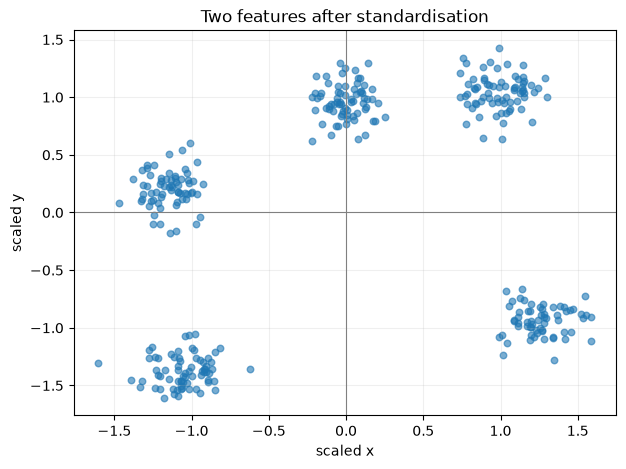

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], s=22, alpha=.6)
ax.set(title='Two features after standardisation', xlabel='scaled x', ylabel='scaled y')
ax.axhline(0, color='gray', linewidth=.8)
ax.axvline(0, color='gray', linewidth=.8)
ax.grid(alpha=.2)
plt.show()

## 5. How many groups should we ask K-means to find?

K-means requires the number of groups, `K`, **in advance**. The method does not automatically know the correct value.

Two standard tools help us compare candidate values:

- **Elbow plot (inertia):** Within-cluster squared distances decrease as more clusters are added. Look for a change from steep improvement to slower improvement; the elbow may not be obvious.
- **Silhouette score:** Compares how close a point is to its own cluster with how far it is from other clusters. The average score ranges from −1 to +1; higher values generally indicate better-separated groups.

These are **diagnostics**, not proofs that the groups have useful real-world meaning. For this teaching dataset, we will compare `K = 2` through `K = 9` and inspect the plots before deciding.

 K  inertia  silhouette
 2  324.076       0.529
 3  134.056       0.667
 4   48.879       0.751
 5   13.483       0.803
 6   12.392       0.700
 7   11.291       0.611
 8   10.323       0.527
 9    9.343       0.437


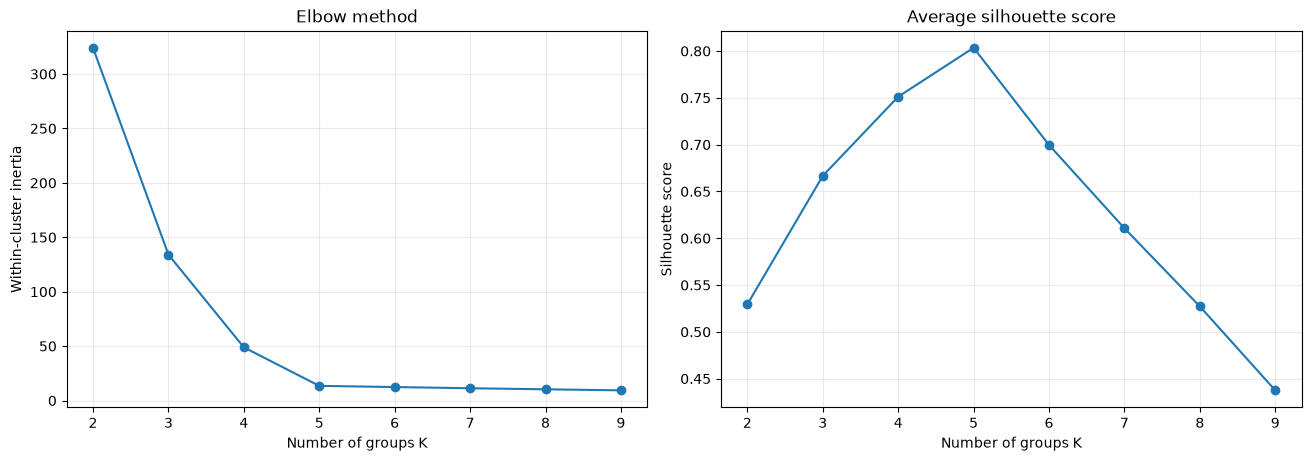

In [9]:
rows = []
for k in range(2, 10):
    candidate = KMeans(n_clusters=k, random_state=42, n_init=15)
    candidate_labels = candidate.fit_predict(X_scaled)
    rows.append({'K': k,
                 'inertia': candidate.inertia_,
                 'silhouette': silhouette_score(X_scaled, candidate_labels)})
k_results = pd.DataFrame(rows)
print(k_results.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].plot(k_results['K'], k_results['inertia'], marker='o')
axes[0].set(title='Elbow method', xlabel='Number of groups K', ylabel='Within-cluster inertia')
axes[1].plot(k_results['K'], k_results['silhouette'], marker='o')
axes[1].set(title='Average silhouette score', xlabel='Number of groups K', ylabel='Silhouette score')
for ax in axes:
    ax.set_xticks(k_results['K'])
    ax.grid(alpha=.25)
plt.show()

In [10]:
best_k_by_silhouette = int(k_results.loc[k_results['silhouette'].idxmax(), 'K'])
print('Highest silhouette score in the tested range is at K =', best_k_by_silhouette)
print('For this introductory dataset, we will demonstrate K=5.')
assert best_k_by_silhouette == 5, 'Unexpected teaching dataset structure; inspect the plot before continuing.'

Highest silhouette score in the tested range is at K = 5
For this introductory dataset, we will demonstrate K=5.


**Student discussion:** Would the silhouette-selected `K` always be the most useful value in a business or scientific problem? What if the data contained a single outlier far away from every other point?

## 6. Train the K-means model

Now that we have inspected candidate values, we fit **five** clusters to the standardised features.

- `random_state=42` makes this exercise reproducible.
- `n_init=15` uses multiple initial centroid selections and keeps the solution with the lowest inertia, reducing dependence on one unlucky starting point.
- `fit_predict` trains the model and returns the assigned group for each training observation.

We will also convert centroid positions back to the original coordinate units so students can interpret them on the first scatterplot.

In [11]:
K = 5
model = KMeans(n_clusters=K, random_state=42, n_init=15)
cluster_labels = model.fit_predict(X_scaled)
centres_scaled = model.cluster_centers_
centres_original = scaler.inverse_transform(centres_scaled)

clustered = data.copy()
clustered['cluster'] = cluster_labels
centre_table = pd.DataFrame(centres_original, columns=['centroid_x', 'centroid_y'])
centre_table.insert(0, 'cluster', range(K))
counts = clustered['cluster'].value_counts().sort_index().rename('observations')
centre_table['observations'] = centre_table['cluster'].map(counts)
print('Cluster centroids in the original coordinate units:')
print(centre_table.round(2).to_string(index=False))

Cluster centroids in the original coordinate units:
 cluster  centroid_x  centroid_y  observations
       0        1.74       15.67            66
       1       10.91       22.07            72
       2        2.15        3.67            71
       3       12.06        6.99            63
       4        6.66       21.46            71


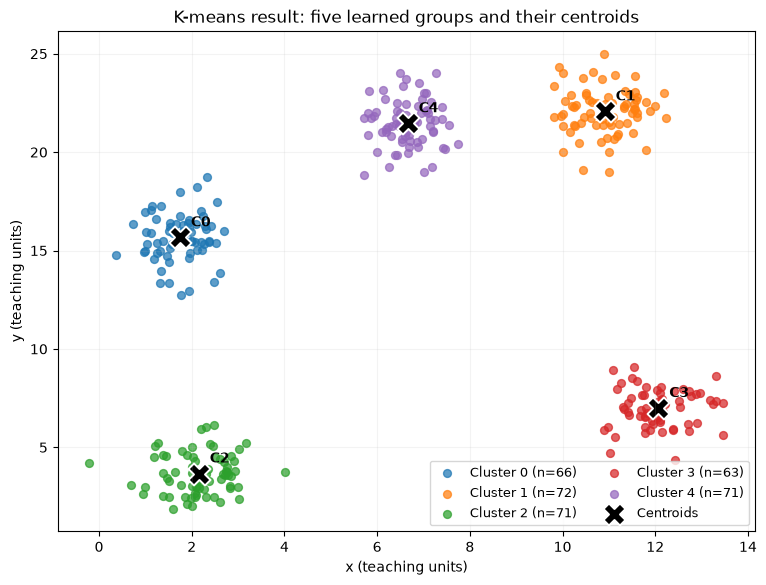

In [12]:
fig, ax = plt.subplots(figsize=(9, 6.5))
for cl in range(K):
    part = clustered[clustered['cluster'] == cl]
    ax.scatter(part['x'], part['y'], s=32, alpha=.72, label=f'Cluster {cl} (n={len(part)})')
ax.scatter(centres_original[:, 0], centres_original[:, 1], marker='X', s=250,
           c='black', linewidth=1.4, edgecolor='white', label='Centroids')
for j, (cx, cy) in enumerate(centres_original):
    ax.annotate(f'C{j}', (cx, cy), xytext=(8, 8), textcoords='offset points', weight='bold')
ax.set(title='K-means result: five learned groups and their centroids',
       xlabel='x (teaching units)', ylabel='y (teaching units)')
ax.legend(loc='best', ncol=2, fontsize=9)
ax.grid(alpha=.15)
plt.show()

### How to interpret this result

Each point receives a **cluster label**, but the labels have **no intrinsic meaning**. A cluster may simply consist of observations with larger `y` values, or observations near the bottom left of the plot. You must look at its centroid, spread, size and domain context before giving it a descriptive name.

The centroids should appear near the middle of their associated points. Notice that the software does not connect the points with lines because there is no chronological or route ordering here.

In [13]:
profile = clustered.groupby('cluster').agg(
    n=('observation_id', 'size'), mean_x=('x', 'mean'), mean_y=('y', 'mean'),
    sd_x=('x', 'std'), sd_y=('y', 'std'))
print('Cluster profiles:')
print(profile.round(2).to_string())

Cluster profiles:
          n  mean_x  mean_y  sd_x  sd_y
cluster                                
0        66    1.74   15.67  0.51  1.19
1        72   10.91   22.07  0.62  1.16
2        71    2.15    3.67  0.67  1.00
3        63   12.06    6.99  0.65  0.97
4        71    6.66   21.46  0.49  1.15


## 7. Evaluate the cluster structure

Unlike supervised classification, this dataset provides **no ground-truth class labels**. Therefore, classification measures such as **accuracy, precision, recall, F1-score or a confusion matrix are not appropriate here**.

Instead we report:

- **Silhouette coefficient:** Higher typically indicates more separated, cohesive clusters.
- **Davies–Bouldin index:** Lower typically indicates better separation relative to within-cluster scatter.
- **Inertia:** The within-cluster sum of squared distances; meaningful for comparisons only under comparable scaling and model setup.
- **Cluster sizes:** Very small groups may be difficult to justify without additional evidence.

A score is a description of geometry, **not** proof that the discovered groups reflect real categories.

In [14]:
silhouette = silhouette_score(X_scaled, cluster_labels)
db = davies_bouldin_score(X_scaled, cluster_labels)
print(f'Silhouette coefficient: {silhouette:.3f} (higher is generally better)')
print(f'Davies–Bouldin index: {db:.3f} (lower is generally better)')
print(f'Inertia (on scaled features): {model.inertia_:.2f}')
print('Cluster sizes:', counts.to_dict())

Silhouette coefficient: 0.803 (higher is generally better)
Davies–Bouldin index: 0.272 (lower is generally better)
Inertia (on scaled features): 13.48
Cluster sizes: {0: 66, 1: 72, 2: 71, 3: 63, 4: 71}


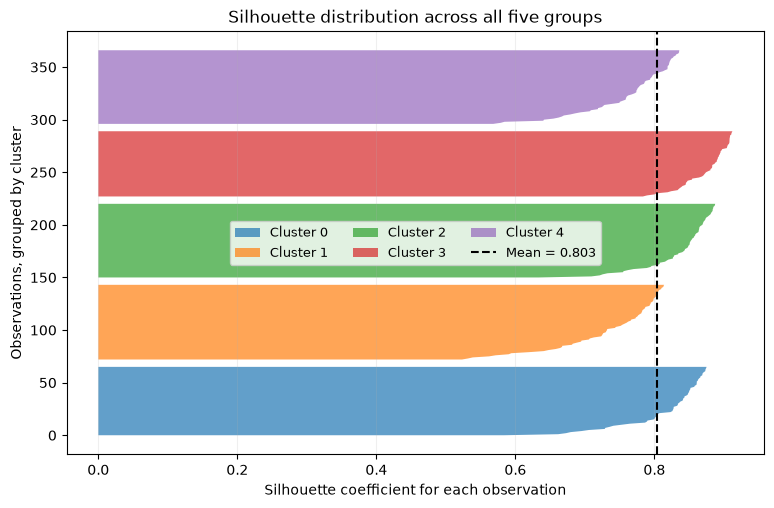

In [15]:
per_sample = silhouette_samples(X_scaled, cluster_labels)
fig, ax = plt.subplots(figsize=(9, 5.5))
start = 0
for cl in range(K):
    vals = np.sort(per_sample[cluster_labels == cl])
    ax.fill_betweenx(np.arange(start, start+len(vals)), 0, vals, alpha=.7, label=f'Cluster {cl}')
    start += len(vals) + 6
ax.axvline(silhouette, linestyle='--', color='black', label=f'Mean = {silhouette:.3f}')
ax.set(title='Silhouette distribution across all five groups',
       xlabel='Silhouette coefficient for each observation', ylabel='Observations, grouped by cluster')
ax.legend(ncol=3, fontsize=9)
ax.grid(axis='x', alpha=.2)
plt.show()

### Discuss the evaluation

1. Why is it misleading to call the silhouette score "accuracy"?
2. If all 343 points were assigned to one cluster, could we compute the standard silhouette coefficient? Why not?
3. Why does inertia usually decrease as `K` increases, even when extra clusters are not useful?

## 8. What does the model do with new observations?

A fitted K-means model assigns a **new point to the nearest learned centroid** in the same scaled feature space.

This is useful for an educational demonstration, but it is **not** an outcome prediction such as salary, GPA or a diagnosis. The result is simply a cluster membership, and the clusters may have no independently verified semantic interpretation.

We must pass new points through the **same fitted scaler** before calling `model.predict`.

In [16]:
new_points = pd.DataFrame([
    {'x': 2.0, 'y': 4.0},
    {'x': 1.7, 'y': 16.2},
    {'x': 6.8, 'y': 21.8},
    {'x': 10.9, 'y': 22.6},
    {'x': 12.3, 'y': 7.4},
], columns=['x', 'y'])
new_scaled = scaler.transform(new_points)
new_points['predicted_cluster'] = model.predict(new_scaled)
print(new_points.to_string(index=False))

   x    y  predicted_cluster
 2.0  4.0                  2
 1.7 16.2                  0
 6.8 21.8                  4
10.9 22.6                  1
12.3  7.4                  3


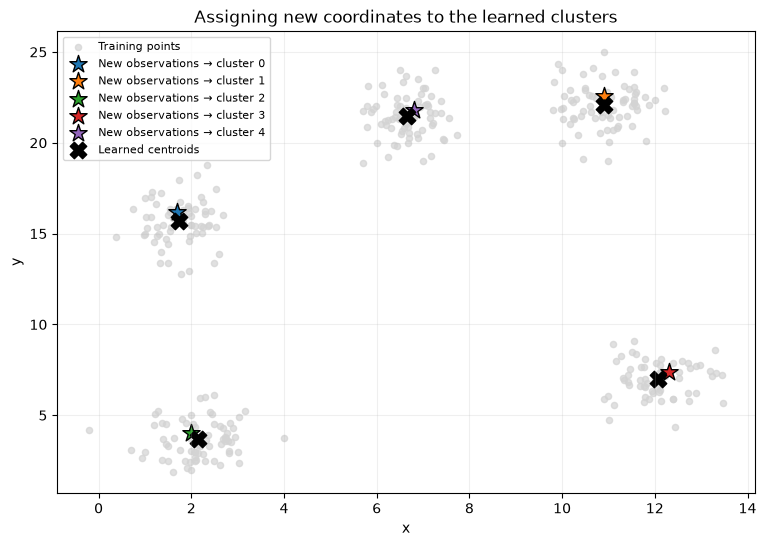

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(data['x'], data['y'], color='lightgray', s=20, alpha=.7, label='Training points')
for cl in range(K):
    rows = new_points[new_points['predicted_cluster'] == cl]
    if len(rows):
        ax.scatter(rows['x'], rows['y'], s=170, marker='*', edgecolor='black',
                   label=f'New observations → cluster {cl}')
ax.scatter(centres_original[:, 0], centres_original[:, 1], color='black', s=140,
           marker='X', label='Learned centroids')
ax.set(title='Assigning new coordinates to the learned clusters', xlabel='x', ylabel='y')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=.2)
plt.show()

### Look inside one prediction

For each new observation, we can compute the distance to **each centroid**, in the standardised feature space. The shortest distance determines the cluster assignment.

In [18]:
example_point = pd.DataFrame([{'x': 7.0, 'y': 22.0}])
point_scaled = scaler.transform(example_point)
dist_to_centroids = model.transform(point_scaled)[0]
print('New point:', example_point.iloc[0].to_dict())
print(pd.DataFrame({'cluster':range(K), 'scaled_distance_to_centroid':dist_to_centroids}).round(3).to_string(index=False))
print('Assigned cluster:', int(model.predict(point_scaled)[0]))

New point: {'x': 7.0, 'y': 22.0}
 cluster  scaled_distance_to_centroid
       0                        1.482
       1                        0.912
       2                        2.659
       3                        2.298
       4                        0.107
Assigned cluster: 4


## 9. Visualise the cluster boundaries

Because this teaching problem has only two features, we can draw the **regions of the plane** that would be assigned to each cluster. This helps connect a new point's location to its predicted cluster.

Note that these are nearest-centroid regions, **not probabilities or certainty estimates**.

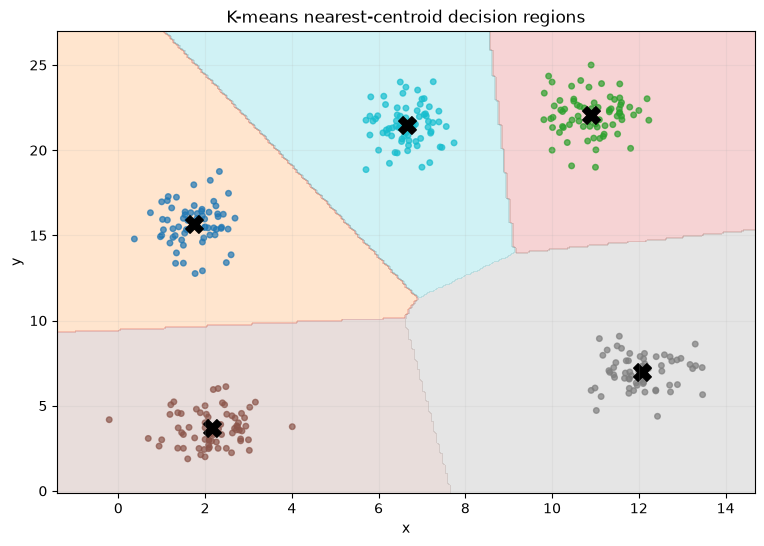

In [19]:
min_x,max_x = X['x'].min()-1.2, X['x'].max()+1.2
min_y,max_y = X['y'].min()-2.0, X['y'].max()+2.0
xx,yy = np.meshgrid(np.linspace(min_x,max_x,250),np.linspace(min_y,max_y,250))
grid_df = pd.DataFrame({'x':xx.ravel(),'y':yy.ravel()})
grid_clusters = model.predict(scaler.transform(grid_df)).reshape(xx.shape)
fig,ax=plt.subplots(figsize=(9,6))
ax.contourf(xx,yy,grid_clusters,levels=np.arange(K+1)-.5,alpha=.20,cmap='tab10')
ax.scatter(X['x'],X['y'],c=cluster_labels,s=16,cmap='tab10',alpha=.7)
ax.scatter(centres_original[:,0],centres_original[:,1],marker='X',c='black',s=160)
ax.set(title='K-means nearest-centroid decision regions',xlabel='x',ylabel='y')
ax.grid(alpha=.15)
plt.show()

## 10. Why repeat initialisations and check stability?

K-means minimises a non-convex objective, so **starting centroids matter**. Multiple initialisations (`n_init`) reduce the chance of retaining a poor local solution.

We can train the algorithm using different random seeds and compare the resulting partitions with the **Adjusted Rand Index (ARI)**. ARI is appropriate here because it compares **two clusterings**, not clusters against true supervised labels. An ARI near 1 means the assignments largely agree after accounting for arbitrary label numbering.

In [20]:
seeds=[1,7,21,42,100]
reference_labels=model.labels_
records=[]
for seed in seeds:
    another=KMeans(n_clusters=5,random_state=seed,n_init=15)
    other_labels=another.fit_predict(X_scaled)
    records.append({'seed':seed,'inertia':another.inertia_,
                    'ARI_vs_reference_partition':adjusted_rand_score(reference_labels,other_labels)})
print(pd.DataFrame(records).round(3).to_string(index=False))

 seed  inertia  ARI_vs_reference_partition
    1   13.483                         1.0
    7   13.483                         1.0
   21   13.483                         1.0
   42   13.483                         1.0
  100   13.483                         1.0


## 11. What difference would skipping scaling make?

This comparison is important because clustering with Euclidean distance depends on the feature units. We compare the two partitions as a **sensitivity analysis**, not because the raw and scaled scores are always directly interchangeable.

Agreement between raw-feature and scaled-feature clusterings (ARI): 1.0


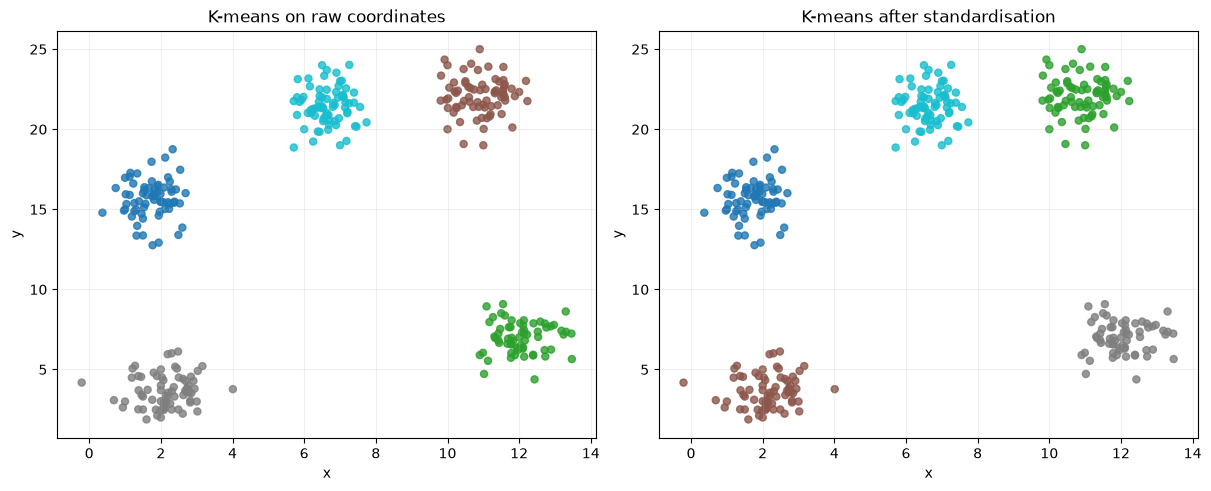

In [21]:
raw_model=KMeans(n_clusters=5,random_state=42,n_init=15)
raw_labels=raw_model.fit_predict(X.to_numpy())
print('Agreement between raw-feature and scaled-feature clusterings (ARI):',
      round(adjusted_rand_score(raw_labels,cluster_labels),3))
fig,axes=plt.subplots(1,2,figsize=(12,4.8),constrained_layout=True)
for ax,labels,title in [(axes[0],raw_labels,'K-means on raw coordinates'),
                         (axes[1],cluster_labels,'K-means after standardisation')]:
    ax.scatter(X['x'],X['y'],c=labels,cmap='tab10',s=26,alpha=.8)
    ax.set(title=title,xlabel='x',ylabel='y')
    ax.grid(alpha=.2)
plt.show()

## 12. Export your assignments and centroid table

These outputs can be opened in Excel or used in another notebook. We retain original `source` information to make it easy to distinguish uploaded coordinates from the synthetic extension.

**Important:** Re-running with a different random seed or `K` can change arbitrary cluster IDs.

In [22]:
clustered.to_csv('cluster_assignments.csv',index=False)
centre_table.to_csv('cluster_centroids.csv',index=False)
print('Saved cluster_assignments.csv and cluster_centroids.csv')

Saved cluster_assignments.csv and cluster_centroids.csv


## 13. Extension: compare a new point against the learned centroids

Try changing the coordinates and rerunning. Predict which cluster will be assigned **before** looking at the output. Then discuss what happens at the boundary between two clusters.

In [23]:
# STUDENT INPUT: change these two numbers and rerun this cell
student_x=5.0
student_y=11.0
student_point=pd.DataFrame([{'x':student_x,'y':student_y}])
student_cluster=int(model.predict(scaler.transform(student_point))[0])
print(f'Point ({student_x:.2f}, {student_y:.2f}) belongs to cluster {student_cluster}.')

Point (5.00, 11.00) belongs to cluster 0.


## 14. Student worksheet and discussion (MLO1, MLO3)

**Understanding (MLO1)**

1. Explain, in your own words, the difference between supervised classification and unsupervised clustering.
2. Which **two operations** are alternated in K-means? Describe them without referring to Python.
3. Why must we decide a value of `K`? What do the elbow and silhouette diagnostics contribute?
4. Why is it inaccurate to describe a silhouette value as "classification accuracy"?
5. Why is drawing a line connecting arbitrary scatterplot observations misleading?
6. Why can a point far away from existing groups distort the results?

**Practical tasks (MLO3)**

7. Change `K` to 4, fit a separate K-means model and plot the groups. Which distinct regions are combined?
8. Change `K` to 6. Does the extra group represent a clearly useful new pattern?
9. Change the `student_x` and `student_y` values in the prediction cell, and explain how the nearest centroid determines the result.
10. Train with `n_init=1` and three random seeds. Does the inertia vary more than with `n_init=15`?
11. Describe when you would **not** use K-means (for example, irregularly shaped groups or categorical-only features).
12. Suggest a real application with two meaningful numerical attributes. What evidence would you need before using the discovered groups to inform a decision?

### Take-home messages

- K-means is an established unsupervised algorithm that uses **distance to centroids**.
- The numerical cluster labels are arbitrary; interpretation requires context.
- Always inspect the features, their units, scaling, `K`, stability and the visual result.
- A visually clean synthetic example is useful for learning, but real-world validation is a separate task.

### References

- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning: with Applications in Python*. Springer. [Open access textbook](https://www.statlearning.com/).
- scikit-learn developers. [KMeans API documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
- scikit-learn developers. [Silhouette analysis](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).

**Source acknowledgement:** The initial 33 `(x,y)` observations come from the lecturer-provided `Kmean2.csv`; the additional 310 observations were generated solely for this educational exercise. The original short notebook was used as the starting point and its plotting/training approach was expanded and corrected.